# AML s26 - Maximal Margin Classifier

Find the hyperplane that separates two classes with the **largest possible margin** 

### Load libraries  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

### Generate linearly separable data

In [2]:
np.random.seed(22)

# Class "-1": cluster around (-2, -2)
X_neg = np.random.randn(20, 2) + np.array([-2, -2])
y_neg = np.full(20, -1)

# Class "+1": cluster around (+2, +2)
X_pos = np.random.randn(20, 2) + np.array([2, 2])
y_pos = np.full(20, 1)

X = np.vstack([X_neg, X_pos])
y = np.hstack([y_neg, y_pos])

print(f"Dataset: {X.shape[0]} points, {(y == 1).sum()} positive, {(y == -1).sum()} negative")

Dataset: 40 points, 20 positive, 20 negative


### Fit classifier

Note: there isn't a dedicated maximal margin classifier in scikit-learn --> use a a **hard-margin SVM** (`C ... cost` very large, linear kernel) -->
it finds the separating hyperplane with the widest margin, assuming the data is linearly separable

In [3]:
clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)

w = clf.coef_[0]          # get weight vector (normal to hyperplane)
b = clf.intercept_[0]     # get bias

margin = 2 / np.linalg.norm(w)

print(f"Decision boundary:  {w[0]:.3f}·x₁ + {w[1]:.3f}·x₂ + {b:.3f} = 0")
print(f"Number of support vectors: {clf.support_vectors_.shape[0]}")
print(f"Margin width:  {margin:.4f}")

Decision boundary:  0.399·x₁ + 0.500·x₂ + -0.032 = 0
Number of support vectors: 3
Margin width:  3.1267


### Visualize the decision boundary and margin

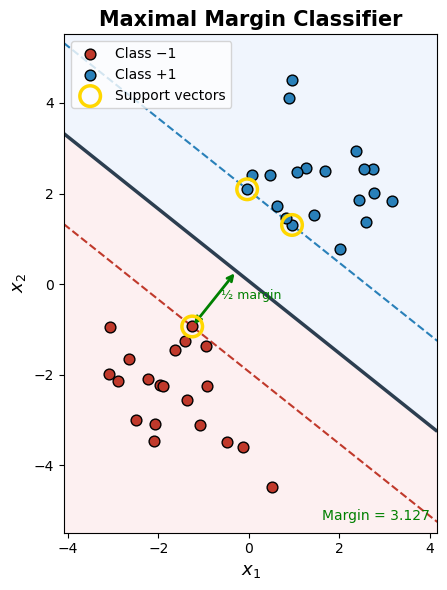

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

# generate grid for decision regions
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 400), np.linspace(x2_min, x2_max, 400))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# shaded regions
ax.contourf(xx, yy, Z, levels=[-1e6, 0, 1e6],  colors=['#FADADD', '#DAE8FC'],  alpha=0.4)

# decision boundary and margin lines
ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'],  colors=['#c0392b', '#2c3e50', '#2980b9'], linewidths=[1.5, 2.5, 1.5])

# data points
ax.scatter(*X_neg.T, color='#c0392b', edgecolors='k', s=60, zorder=3, label='Class −1')
ax.scatter(*X_pos.T, color='#2980b9', edgecolors='k', s=60, zorder=3, label='Class +1')

# support vectors
ax.scatter(*clf.support_vectors_.T, s=220, facecolors='none', edgecolors='gold', linewidths=2.5, zorder=4, label='Support vectors')

# margin width annotation
sv = clf.support_vectors_[0]          # pick one support vector
proj = sv - (np.dot(w, sv) + b) / np.dot(w, w) * w   # foot on boundary
ax.annotate('', xy=proj, xytext=sv,  arrowprops=dict(arrowstyle='<->', color='green', lw=2))
mid = (sv + proj) / 2
ax.text(mid[0] + 0.15, mid[1], f'½ margin', color='green', fontsize=9)

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_aspect('equal')  
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Maximal Margin Classifier', fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.text(0.98, 0.02, f'Margin = {margin:.3f}', transform=ax.transAxes, ha='right', va='bottom', fontsize=10, color='green')

plt.tight_layout()
plt.savefig('maximal_margin_classifier.png', dpi=150)
plt.show()

### Introduce an outlier

Adding a single outlier close to the boundary shows how sensitive the maximal margin classifier is 

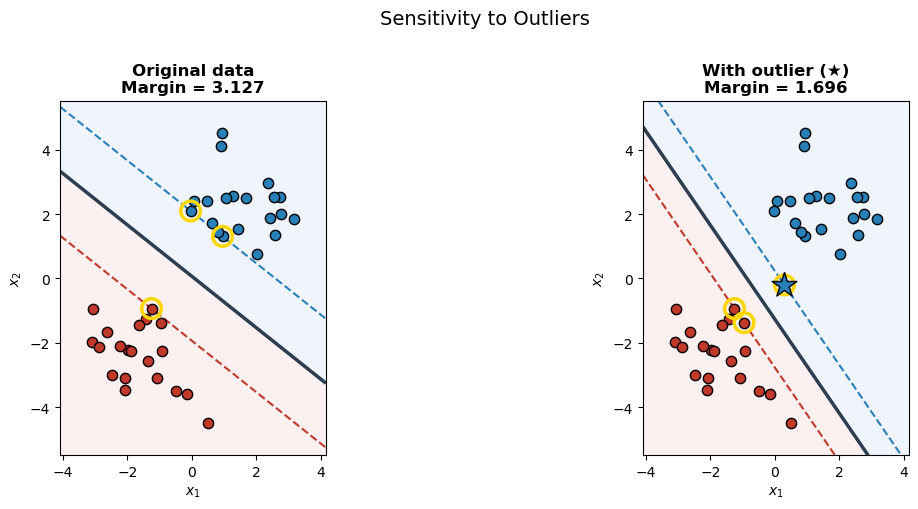

Original margin : 3.127
Margin with outlier: 1.696  (change: -45.8%)


In [5]:
# Add one outlier from class +1 close to the boundary
outlier = np.array([[0.3, -0.2]])
X2 = np.vstack([X, outlier])
y2 = np.hstack([y, [1]])

clf2 = SVC(kernel='linear', C=1e6)
clf2.fit(X2, y2)

w2 = clf2.coef_[0]
b2 = clf2.intercept_[0]
margin2 = 2 / np.linalg.norm(w2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (clf_, X_, y_, title, margin_) in zip(axes, [(clf,  X,  y,  'Original data',   margin),   (clf2, X2, y2, 'With outlier (★)',  margin2)]):

    xx2, yy2 = np.meshgrid(np.linspace(x1_min, x1_max, 300), np.linspace(x2_min, x2_max, 300))
    Z_ = clf_.decision_function(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

    ax.contourf(xx2, yy2, Z_, levels=[-1e6, 0, 1e6],  colors=['#FADADD', '#DAE8FC'], alpha=0.4)
    ax.contour(xx2, yy2, Z_, levels=[-1, 0, 1],  linestyles=['--', '-', '--'], colors=['#c0392b', '#2c3e50', '#2980b9'], linewidths=[1.5, 2.5, 1.5])

    mask_neg = y_ == -1
    ax.scatter(*X_[mask_neg].T, color='#c0392b', edgecolors='k', s=55, zorder=3)
    ax.scatter(*X_[~mask_neg].T, color='#2980b9', edgecolors='k', s=55, zorder=3)
    ax.scatter(*clf_.support_vectors_.T,  s=200,  facecolors='none', edgecolors='gold', linewidths=2.5, zorder=4)

    if 'outlier' in title: 
        ax.scatter(*outlier.T, marker='*', color='#2980b9', edgecolors='k', s=350, zorder=5)

    ax.set_xlim(x1_min, x1_max); ax.set_ylim(x2_min, x2_max)
    ax.set_aspect('equal')  # keeps geometry visually accurate
    ax.set_title(f'{title}\nMargin = {margin_:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.suptitle('Sensitivity to Outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outlier_sensitivity.png', dpi=150)
plt.show()

print(f"Original margin : {margin:.3f}")
print(f"Margin with outlier: {margin2:.3f}  (change: {(margin2 - margin)/margin*100:+.1f}%)")